<a href="https://colab.research.google.com/github/amandammt17/puc-rioMVP_ML/blob/main/MVP%20-%20ML%20%26%20Analytics%3A%20Sales%20Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP - Machine Learning & Analytics: Previsão de Faturamento (Sales Forecasting)


**Nome:** Amanda da Motta Matinha Teixeira  
**Matrícula:** 4052026000442  
**Data:** 05/07/2026  
**Dataset:** [Superstore Sales Dataset](https://www.kaggle.com/datasets/rohitsahoo/sales-forecasting)  
**Tipo de problema:** Regressão

----



# 1. Definição do problema



## 1.1 Descrição do problema

- **Qual é o contexto do problema?** O problema está inserido na dificuldade que empresas de e-commerce enfrentam ao tentar projetar com precisão o faturamento futuro baseando-se apenas no histórico de transações, visto que precisam lidar com um mercado altamente variável.

- **Qual decisão, previsão, classificação, agrupamento ou análise o modelo deve apoiar?** O modelo realizará uma previsão quantitativa do volume de faturamento. A partir dessa projeção preditiva, a ferramenta apoiará a decisão estratégica de alocação de recursos, permitindo que a companhia dimensione de forma otimizada os seus níveis de estoque e a distribuição do orçamento antes mesmo da demanda se concretizar.

- **Quem seria o usuário ou interessado nessa solução?** Os principais interessados e usuários diretos da solução são as áreas de Gestão Financeira (responsável pelo controle do fluxo de caixa e do planejamento orçamentário) e de Suprimentos e Logística (responsável pela aquisição de produtos e pela gestão estratégica da armazenagem).

- **Por que esse problema é relevante?** A relevância do projeto reside em possibilitar a transição de um modelo de gestão puramente reativo para uma atuação proativa. Ao antecipar as receitas com maior confiabilidade estatística, a empresa otimiza a aplicação do seu capital, garante a disponibilidade de produtos para o consumidor final (evitando perdas de vendas) e minimiza os prejuízos operacionais causados por mercadorias ociosas no estoque.

## 1.2 Objetivo do MVP

O objetivo central deste MVP é construir, avaliar e comparar modelos de Machine Learning que sejam capazes de estimar o valor financeiro das vendas futuras a partir de  dados brutos do histórico vendas.


## 1.3 Tipo de problema

**Tipo escolhido:** Regressão  
**Justificativa:** A variável-alvo (target) deste modelo será a coluna Sales (Faturamento / Valor da Venda). Trata-se de uma variável numérica contínua, o que classifica o nosso desafio primariamente como uma tarefa de Regressão. Como o faturamento de cada pedido está atrelado a uma linha do tempo cronológica (Order Date), o modelo atuará em um cenário híbrido de regressão aplicada a um contexto de séries temporais.


## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses iniciais:**
1. Premissa de Continuidade: Assume-se que o comportamento de compra dos clientes, os padrões geográficos e a precificação do passado se manterão consistentes no futuro próximo.
2. Hipótese Sazonal: Hipotetizamos que a extração de atributos temporais (Engenharia de Recursos separando a data exata em Mês e Ano) será suficiente para que algoritmos de regressão tradicionais aprendam a sazonalidade, sem a necessidade de usar algoritmos restritos a séries temporais puras.
3. Restrição de Data Leakage (Vazamento de Dados): Como há uma dependência temporal estrita no mundo real, a divisão do conjunto de dados para treinamento e teste sofrerá uma forte restrição: ela deve ser cronológica. O embaralhamento aleatório (shuffle) comum em outros modelos de ML está terminantemente proibido nesta modelagem.

**Critérios de sucesso:**
- Métrica principal:  MAE (Erro Médio Absoluto). Essa métrica foi escolhida por expressar o erro do faturamento diretamente na moeda do negócio (ex: "o modelo erra em média $ 50 por pedido"), facilitando o entendimento pela diretoria financeira.
- Resultado mínimo esperado: O modelo final de Machine Learning deve reduzir o erro (MAE) superando o baseline estatístico (média simples) em pelo menos 15%.
- Restrição prática: modelos com maior interpretabilidade são preferíveis a modelos "caixa preta".


# 2. Ambiente, bibliotecas e reprodutibilidade




Para garantir que os resultados deste Produto Mínimo Viável (MVP) sejam consistentes, auditáveis e totalmente reprodutíveis em execuções futuras ou em outras máquinas, esta seção consolida todas as dependências do projeto e as configurações de ambiente.

**Aspectos de Reprodutibilidade:**
* **Semente Aleatória (Seed):** Foi definida uma constante global (`SEED = 42`) aplicada tanto ao `numpy` quanto ao parâmetro `random_state` dos algoritmos do `scikit-learn` (como *Random Forest* e *Gradient Boosting*). Isso garante que divisões de dados, subamostragens e inicializações ocorram exatamente da mesma forma em cada execução.
* **Hardware (CPU/GPU):** Os modelos selecionados para este MVP dependem fundamentalmente de processamento em CPU. O uso de GPU não se faz necessário para esta arquitetura computacional.
* **Versões de Dependências:** O código foi estruturado para compatibilidade com versões modernas do ecossistema Python de Ciência de Dados (recomendável `scikit-learn >= 1.2` para suporte otimizado ao parâmetro `sparse_output` no `OneHotEncoder`).


In [1]:
# === Setup básico e reprodutibilidade ===
import os
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, TimeSeriesSplit, RandomizedSearchCV, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error, r2_score,
    silhouette_score
)
from scipy.stats import randint

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)


Python: 3.12.13
Seed: 42


# 3. Seleção e carga dos dados


## 3.1 Fonte dos dados

- Nome do dataset: Superstore Sales
- Link da fonte: https://www.kaggle.com/datasets/rohitsahoo/sales-forecasting
- Por que esse dataset foi escolhido: A base foi escolhida pelo nível de detelhes e qualidade dos dados. Consiste em um histórico transacional de um e-commerce/varejo dos EUA, contendo detalhes de cada pedido, como a data da compra, dados de logística, segmentação do cliente, categoria do produto e detalhes financeiros.
- Questões de ética, privacidade, confidencialidade ou licença: O dataset foi extraído de uma base pública (Kaggle) e está hospedado em um repositório aberto no GitHub, garantindo o acesso direto e a reprodutibilidade do notebook sem a necessidade de downloads manuais ou chaves de API.



## 3.2 Carga dos dados


In [2]:
# parte principal da carga de dados
url = "https://raw.githubusercontent.com/amandammt17/puc-rioMVP_ML/refs/heads/main/Sale%20Forecasting%20-%20MVP%20ML%20%26%20Analytics.csv"
df = pd.read_csv(url)

df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


## 3.3 Visão geral do dataset



In [3]:
print("Formato do dataset:", df.shape)
print("\nTipos de dados:")
display(df.dtypes.to_frame("tipo"))

Formato do dataset: (9800, 18)

Tipos de dados:


,tipo
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [4]:
print("\nValores ausentes por coluna:")
display(df.isna().sum().to_frame("ausentes"))


Valores ausentes por coluna:


,ausentes
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [5]:
print("\nDuplicatas:", df.duplicated().sum())



Duplicatas: 0


In [6]:
display(df.sample(5, random_state=SEED))

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
532,533,US-2018-129441,07/09/2018,11/09/2018,Standard Class,JC-15340,Jasper Cacioppo,Consumer,United States,Los Angeles,California,90032.0,West,FUR-FU-10000448,Furniture,Furnishings,Tenex Chairmats For Use With Carpeted Floors,47.94
872,873,CA-2015-148488,10/12/2015,15/12/2015,Standard Class,SM-20005,Sally Matthias,Consumer,United States,New York City,New York,10009.0,East,OFF-PA-10004470,Office Supplies,Paper,"Adams Write n' Stick Phone Message Book, 11"" X...",11.36
1149,1150,CA-2016-112452,04/04/2016,04/04/2016,Same Day,NC-18340,Nat Carroll,Consumer,United States,Lansing,Michigan,48911.0,Central,TEC-PH-10000307,Technology,Phones,Shocksock Galaxy S4 Armband,10.95
2287,2288,US-2018-112928,01/06/2018,05/06/2018,Second Class,BB-10990,Barry Blumstein,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AP-10002287,Office Supplies,Appliances,Eureka Sanitaire Multi-Pro Heavy-Duty Upright...,17.48
4038,4039,CA-2015-110786,29/12/2015,02/01/2016,Standard Class,AJ-10795,Anthony Johnson,Corporate,United States,San Francisco,California,94110.0,West,OFF-PA-10000528,Office Supplies,Paper,Xerox 1981,21.12


## 3.4 Dicionário de dados


| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| **Row ID** | texto | Identificador sequencial da linha. | não | Excluído por ser apenas um índice sem valor preditivo. |
| **Order ID** | texto | Identificador único do pedido/compra. | não | Excluído para evitar ruído e memorização pelo modelo. |
| **Order Date** | data | Data em que o pedido foi finalizado. | não | Será decomposta em novas variáveis numéricas (Mês, Ano) via Engenharia de Atributos. |
| **Ship Date** | data | Data de envio logístico do produto. | não | Excluída para evitar *data leakage* (não sabemos a data real de envio no instante da compra). |
| **Ship Mode** | categórica | Modalidade de frete/envio escolhida. | sim | Diferentes modais de envio podem ter correlação com o volume financeiro do ticket. |
| **Customer ID** | texto | Código único identificador do cliente. | não | Excluído por não permitir generalização para clientes novos. |
| **Customer Name**| texto | Nome completo do cliente comprador. | não | Excluído por ser dado identificador (ruído para regressão). |
| **Segment** | categórica | Perfil do cliente (Consumidor, Corporativo, etc.). | sim | Ajuda o algoritmo a diferenciar o poder de compra e o volume do ticket. |
| **Country** | categórica | País onde a transação ocorreu. | não | Excluído por possuir variância zero (todos os registros são dos EUA). |
| **City** | categórica | Cidade da entrega do pedido. | não | Excluída por alta cardinalidade (centenas de cidades únicas pulverizam os dados). |
| **State** | categórica | Estado do endereço de entrega. | não | Excluída por redundância geográfica com 'Region' e para evitar o aumento excessivo de dimensionalidade no One-Hot Encoding. |
| **Postal Code** | texto | Código postal (CEP) do destino. | não | Excluído por redundância geográfica e alta cardinalidade. |
| **Region** | categórica | Região geográfica (East, West, South, etc.). | sim | Agrupamento macro geográfico com alto potencial preditivo. |
| **Product ID** | texto | Código único no sistema para o produto. | não | Excluído devido à alta cardinalidade. |
| **Category** | categórica | Categoria macro do item (ex: Móveis, Tecnologia).| sim | Atributo base fundamental para definir a faixa de faturamento do item. |
| **Sub-Category** | categórica | Subcategoria do produto vendido. | sim | Adiciona granularidade essencial à Categoria principal. |
| **Product Name** | texto | Descrição em texto livre do produto. | não | Excluído pois textos não estruturados dificultam o aprendizado sem NLP prévio. |
| **Sales** | alvo | Faturamento financeiro do item vendido. | alvo | Variável contínua que o nosso algoritmo tentará prever. |

# 4. Análise exploratória dos dados


## 4.1 Distribuição do target

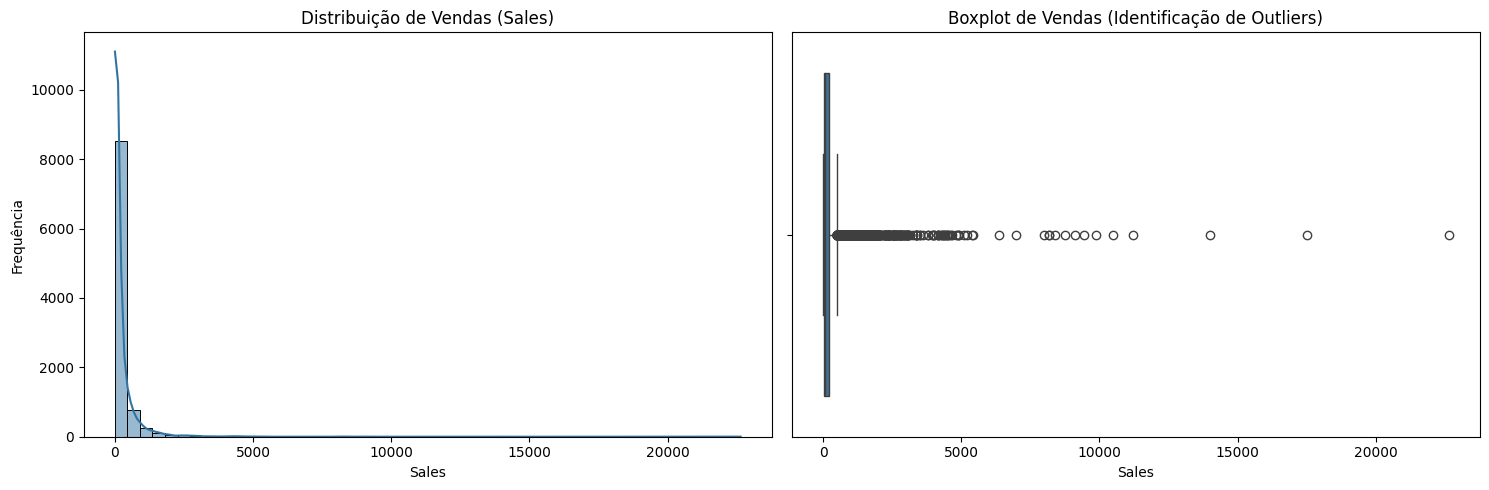

count     9800.000000
mean       230.769059
std        626.651875
min          0.444000
25%         17.248000
50%         54.490000
75%        210.605000
max      22638.480000
Name: Sales, dtype: float64


In [7]:
# 1. Distribuição da Variável-Alvo (Sales)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histograma
sns.histplot(df['Sales'], bins=50, kde=True, ax=axes[0], color='#3274A1')
axes[0].set_title('Distribuição de Vendas (Sales)')
axes[0].set_ylabel('Frequência')

# Boxplot para visualizar outliers
sns.boxplot(x=df['Sales'], ax=axes[1], color='#3274A1')
axes[1].set_title('Boxplot de Vendas (Identificação de Outliers)')

plt.tight_layout()
plt.show()

# Estatísticas descritivas do target
print(df['Sales'].describe())

**O que o gráfico indica:**
A distribuição da variável `Sales` é fortemente assimétrica à direita (distribuição de cauda longa). A imensa maioria dos pedidos possui valores baixos (a mediana é inferior a $ 60), enquanto o boxplot revela a presença de *outliers* extremos (pedidos que chegam a milhares de dólares).

**Como isso influencia a modelagem:**
* **Métricas de Erro:** O uso do Erro Quadrático Médio (MSE/RMSE) seria muito penalizado por esses *outliers*. Por isso, a decisão de usar o Erro Médio Absoluto (MAE) definida nos critérios de sucesso é a mais correta técnica e analiticamente.
* **Algoritmos:** Modelos lineares puros sofrem com assimetria severa. Por isso, além dos algoritmos de regressão lineares, serão testados também algoritmos de árvore de decisão.

## 4.2 Distribuição de variáveis importantes

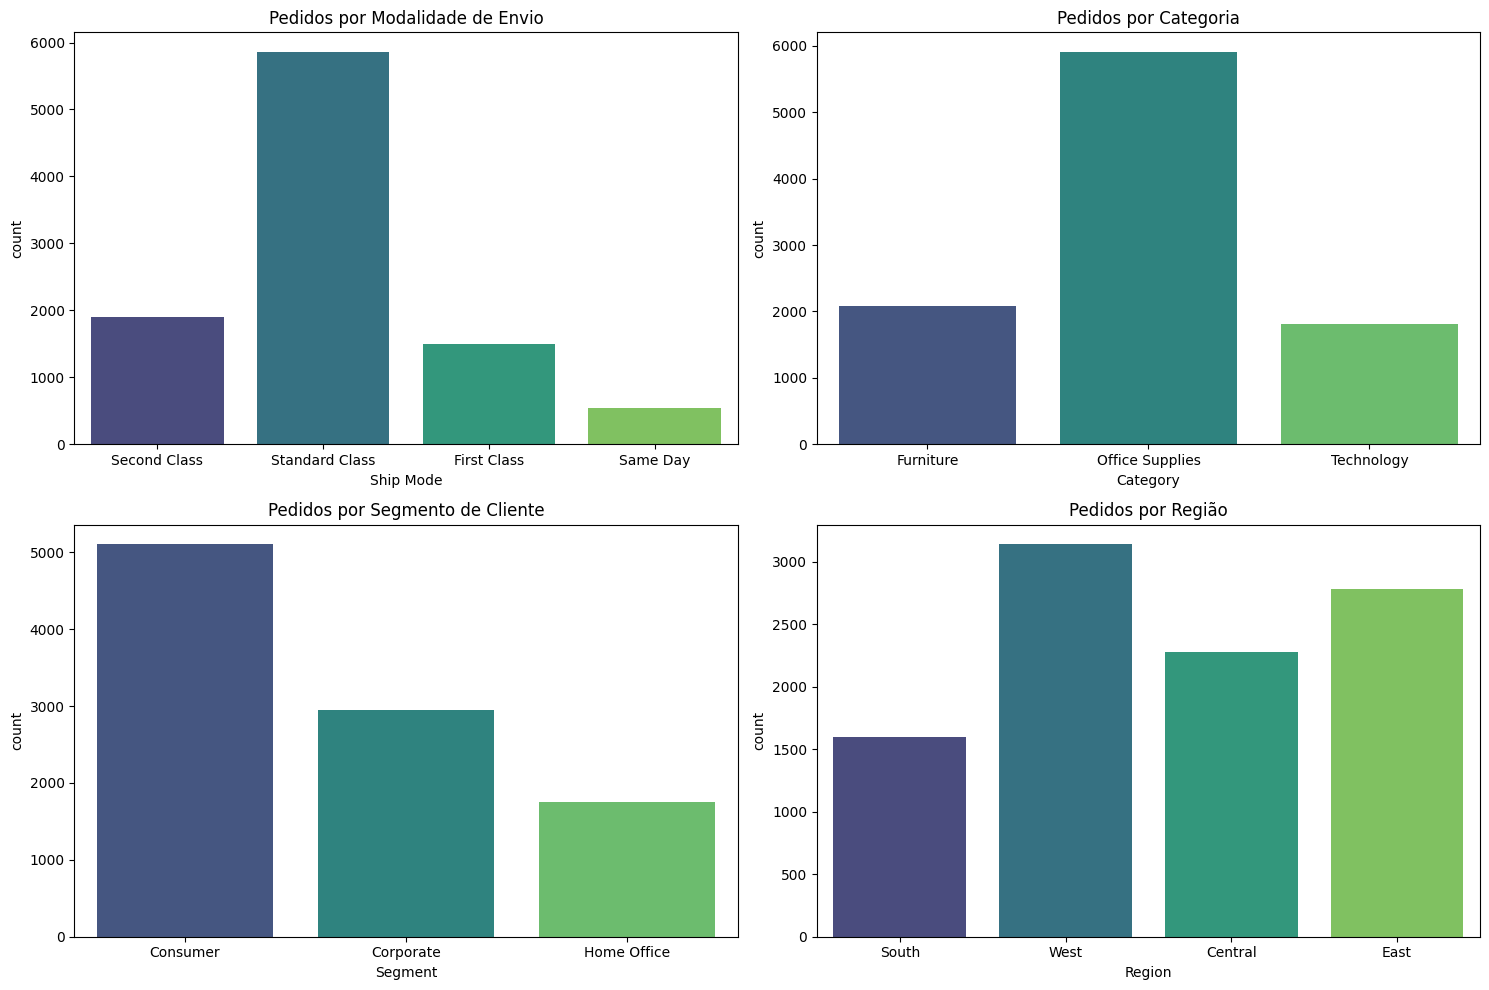

In [8]:
# 2. Distribuição das principais variáveis categóricas
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.countplot(data=df, x='Ship Mode', ax=axes[0,0], palette='viridis')
axes[0,0].set_title('Pedidos por Modalidade de Envio')

sns.countplot(data=df, x='Category', ax=axes[0,1], palette='viridis')
axes[0,1].set_title('Pedidos por Categoria')

sns.countplot(data=df, x='Segment', ax=axes[1,0], palette='viridis')
axes[1,0].set_title('Pedidos por Segmento de Cliente')

sns.countplot(data=df, x='Region', ax=axes[1,1], palette='viridis')
axes[1,1].set_title('Pedidos por Região')

plt.tight_layout()
plt.show()

**O que os gráficos indicam:**
Existe um desbalanceamento natural no volume de pedidos em todos os recortes analisados:
* **Modalidade de Envio:** A esmagadora maioria dos clientes opta pelo "Standard Class" (envio padrão), enquanto envios urgentes como "Same Day" são ocorrências estatisticamente raras.
* **Categoria:** "Office Supplies" tem o maior volume transacional (maior giro), embora possivelmente não traga o maior faturamento absoluto por item.
* **Segmento:** "Consumer" é majoritário frente ao "Corporate" e "Home Office".
* **Região:** O volume é relativamente balanceado, com "West" e "East" liderando levemente.


**Como isso influencia a modelagem:**
* A presença majoritária do "Standard Class" e do "Consumer" cria um perfil base para o algoritmo (o comportamento padrão do cliente médio).
* Não há categorias ou modalidades tão raras que exijam remoção manual (ex: não há nenhuma classe com apenas 2 ocorrências).
* O *One-Hot Encoding* lidará perfeitamente com essas colunas, pois os agrupamentos possuem baixa cardinalidade (poucos valores únicos), o que previne a explosão de dimensionalidade no treinamento do nosso modelo.

## 4.3 Relação entre variáveis e target

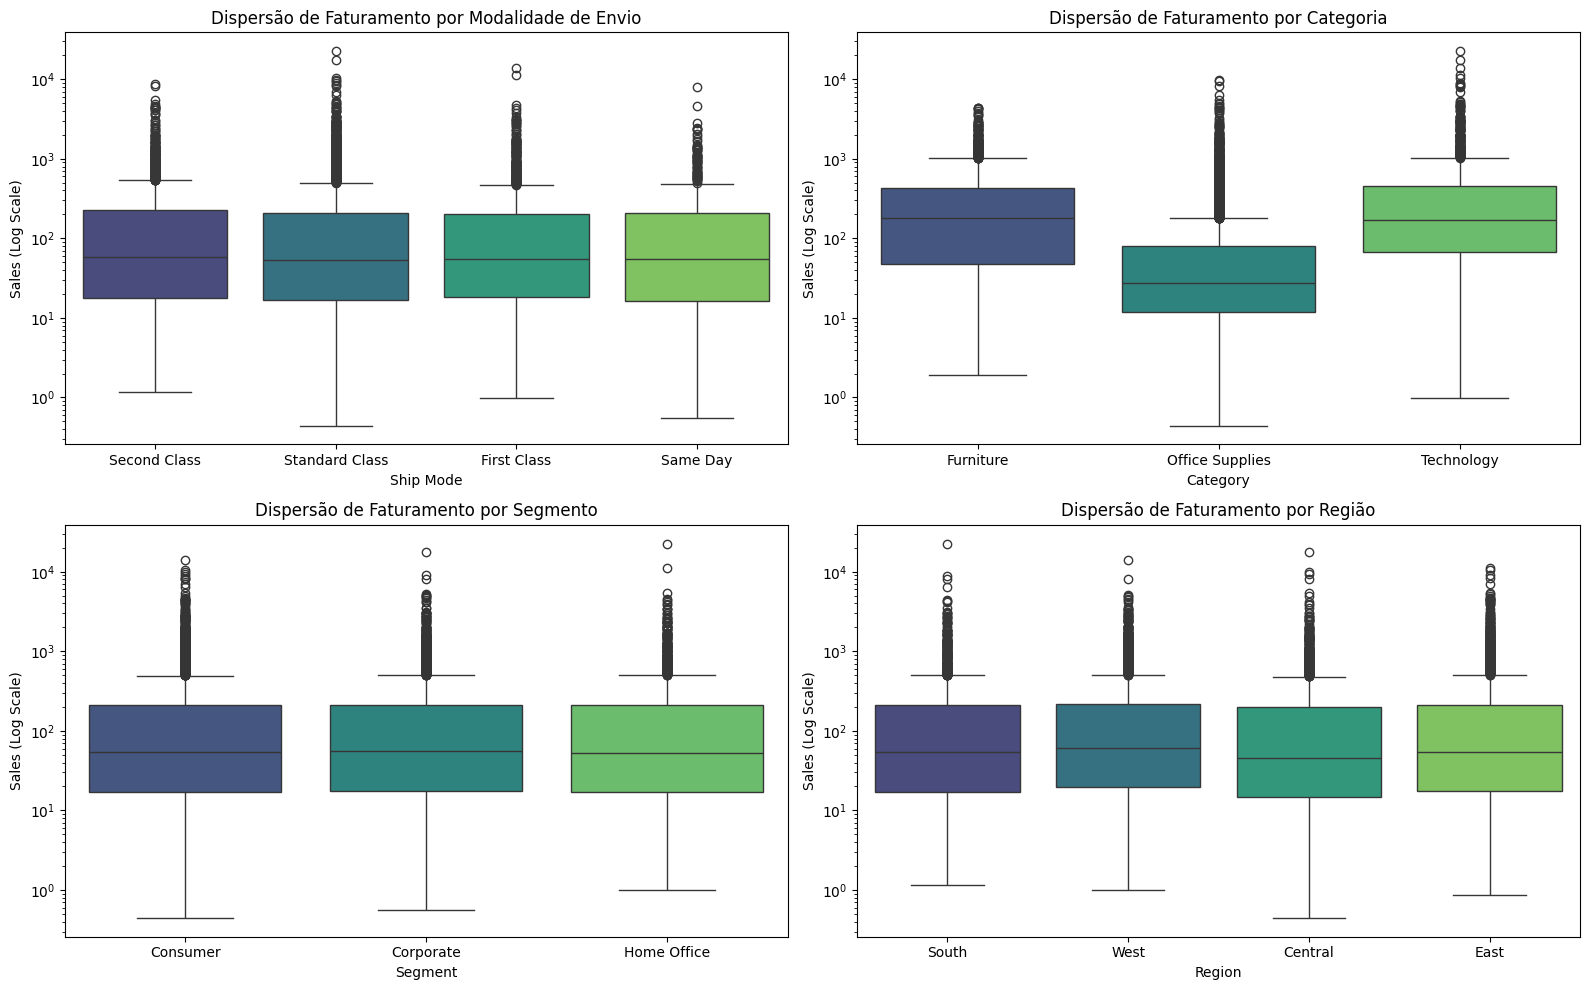

In [9]:
# 3. Relação entre Variáveis Categóricas e o Faturamento (Sales)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Aplicaremos log apenas na visualização para enxergar melhor devido aos outliers
# Definindo uma função rápida para facilitar a plotagem com escala logarítmica
def plot_boxplot(x_col, ax, title):
    sns.boxplot(data=df, x=x_col, y='Sales', ax=ax, palette='viridis')
    ax.set_title(title)
    ax.set_yscale('log')
    ax.set_ylabel('Sales (Log Scale)')

# Plotando os cruzamentos
plot_boxplot('Ship Mode', axes[0, 0], 'Dispersão de Faturamento por Modalidade de Envio')
plot_boxplot('Category', axes[0, 1], 'Dispersão de Faturamento por Categoria')
plot_boxplot('Segment', axes[1, 0], 'Dispersão de Faturamento por Segmento')
plot_boxplot('Region', axes[1, 1], 'Dispersão de Faturamento por Região')


plt.tight_layout()
plt.show()

**O que os gráficos indicam:**
Ao plotar as vendas em escala logarítmica (para atenuar o impacto visual dos *outliers*), notamos comportamentos distintos:
* **Modalidade de Envio:** A mediana do "Same Day" (Envio no mesmo dia) é levemente superior, mas em geral, as distribuições financeiras não sofrem alterações drásticas com base no frete escolhido.
* **Categoria:** É o atributo com maior poder de diferenciação. "Technology" possui uma mediana visivelmente superior e limites de valores mais altos do que "Office Supplies".
* **Segmento e Região:** As medianas de faturamento são surpreendentemente similares entre os diferentes segmentos de clientes e regiões geográficas. A dispersão também é muito parecida.


**Como isso influencia a modelagem:**
* A variável `Category` confirma ser o preditor não-temporal mais forte do modelo.
* Embora `Region` e `Segment` não apresentem diferenças grotescas nas medianas individuais, suas interações com outras variáveis (ex: a combinação de uma Região específica em um Mês específico) podem revelar padrões ocultos para os algoritmos. Por isso, serão mantidas.


## 4.4 Síntese da análise exploratória




Com base nas visualizações e estatísticas geradas, consolidamos os seguintes aprendizados que guiarão a próxima etapa do projeto:

**O target está balanceado?**
Como trata-se de um problema de Regressão, avaliamos a distribuição e não as "classes". O target (Sales) possui forte assimetria à direita (cauda longa). A grande maioria dos pedidos possui baixo valor (mediana inferior a $ 60), mas há uma quantidade expressiva de outliers na extremidade superior (pedidos de milhares de dólares).

**Existem valores ausentes relevantes?**
Não. A base de dados transacional do Superstore é estruturalmente consistente. As colunas selecionadas para modelagem (Category, Segment, Region, Ship Mode, Sales e Order Date) não apresentam dados faltantes que exijam técnicas complexas de imputação.

**Há variáveis com escala muito diferente?**
As variáveis preditoras originais selecionadas são todas categóricas (textos) ou datas. Ao aplicarmos o pré-processamento, elas se tornarão colunas binárias (0 e 1, via One-Hot Encoding) e variáveis numéricas cíclicas (Dia, Mês). Dessa forma, a disparidade de escala não será um ofensor crítico, mas manteremos o uso do StandardScaler no Pipeline por precaução e boas práticas.

**Há categorias raras?**
Nas variáveis selecionadas para modelagem, não. Todas as classes dentro de Category, Segment, Region e Ship Mode possuem volume amostral estatisticamente representativo. Categorias com altíssima cardinalidade e pulverização (como City e Product ID) já foram intencionalmente descartadas no dicionário de dados.

**Existem padrões que sugerem quais modelos podem funcionar melhor?**
A forte presença de outliers e a assimetria do faturamento indicam que modelos lineares clássicos sofrerão para representar a realidade. Isso fortalece a tese de que algoritmos baseados em particionamento espacial, como Árvores de Decisão e Random Forest, apresentarão performance superior por serem mais robustos a distribuições não-normais.

**Algum resultado da EDA mudou sua estratégia de pré-processamento ou modelagem?**
Sim, tivemos três grandes decisões derivadas da EDA:

- Manutenção de Outliers: Optamos por não remover os pedidos de alto valor. Eles não são erros de digitação, são vendas reais (ex: lote de computadores para empresas). Removê-los impediria o modelo de aprender a prever o alto faturamento.

- Mudança de Métrica: Devido aos outliers, confirmamos o uso do MAE (Erro Médio Absoluto) como métrica de sucesso primária em detrimento do MSE/RMSE, pois este último puniria excessivamente o modelo pelos valores extremos.

- Engenharia de Recursos Temporal: A estagnação visual ao cruzar o faturamento com variáveis estáticas (como Região e Segmento) tornou evidente que precisamos criar variáveis de tempo (Mês e Ano, extraídas de Order Date) para dar poder preditivo ao algoritmo via sazonalidade.

# 5. Preparação dos dados e divisão treino/teste





## 5.1. Engenharia de Recursos e Seleção de Atributos


Antes de realizar a divisão, precisamos transformar a coluna `Order Date` de texto para o formato nativo de data (`datetime`), ordenar o dataset por essa coluna (para evitar Vazamento de Dados) e extrair seus componentes cíclicos e sazonais (`Ano` e `Mês`). Em seguida, filtraremos o DataFrame mantendo apenas as variáveis preditoras selecionadas e o target.



In [10]:
# ==========================================
# 1. Ajuste do Formato de Data e Ordenação
# ==========================================
# Garantindo que a data seja reconhecida corretamente pelo Pandas e sabendo que a data neste dataset tem formato de %d/%m/%Y
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

# Ordenando o dataset de forma cronológica (Essencial para Séries Temporais/Regressão Temporal) e por índice (para garantir sempre a mesma ordenação entre pedidos em um mesmo dia)
df = df.sort_values(by=['Order Date','Row ID']).reset_index(drop=True)

# ==========================================
# 2. Engenharia de Recursos (Feature Engineering)
# ==========================================
# Extraindo componentes temporais que o modelo consegue interpretar matematicamente
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

# ==========================================
# 3. Filtragem de Colunas (Seleção de Atributos)
# ==========================================
# Definindo as colunas que decidimos manter (X) e o target (y)
features_desejadas = ['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category', 'Year', 'Month']
target = 'Sales'

X = df[features_desejadas]
y = df[target]

## 5.2. Divisão treino/teste (Corte Cronológico)


Como dito anteriormente, para evitar vazamento de dados, a divisão do dataset em treino/teste adotada será **estritamente cronológica**:
1. Ordenamos o dataset inteiramente pela data de compra (`Order Date`), feito na célula anterior.
2. Separaremos os primeiros **80% dos dados para o conjunto de Treino** (representando o passado).
3. Reservaremos os **20% finais para o conjunto de Teste** (representando o futuro que queremos prever).
4. Desativaremos a opção de _Shuffle_ da função de divisão de dados para que a ordem dos dados seja mantida

In [11]:
# ==========================================
# 4. Divisão Cronológica entre Treino e Teste
# ==========================================
# O parâmetro shuffle=False impede o embaralhamento e garante o corte temporal
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# ==========================================
# 5. Validação e Inspeção das Divisões
# ==========================================
print("--- Validação da Preparação dos Dados ---")
print(f"Tamanho total do dataset original: {df.shape[0]} linhas")
print(f"X_train (Treino - Passado): {X_train.shape[0]} linhas ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"X_test  (Teste - Futuro):   {X_test.shape[0]} linhas ({X_test.shape[0]/len(df)*100:.1f}%)")

print("\nPeríodo coberto pelo Treino:")
print(f"De: {df['Order Date'].iloc[X_train.index].min().strftime('%d/%m/%Y')} até {df['Order Date'].iloc[X_train.index].max().strftime('%d/%m/%Y')}")

print("\nPeríodo coberto pelo Teste (Validação do Futuro):")
print(f"De: {df['Order Date'].iloc[X_test.index].min().strftime('%d/%m/%Y')} até {df['Order Date'].iloc[X_test.index].max().strftime('%d/%m/%Y')}")

print("\nExemplo das primeiras linhas dos atributos de treino (X_train):")
display(X_train.head())

--- Validação da Preparação dos Dados ---
Tamanho total do dataset original: 9800 linhas
X_train (Treino - Passado): 7840 linhas (80.0%)
X_test  (Teste - Futuro):   1960 linhas (20.0%)

Período coberto pelo Treino:
De: 03/01/2015 até 20/07/2018

Período coberto pelo Teste (Validação do Futuro):
De: 20/07/2018 até 30/12/2018

Exemplo das primeiras linhas dos atributos de treino (X_train):


,Ship Mode,Segment,Region,Category,Sub-Category,Year,Month
0,Standard Class,Consumer,Central,Office Supplies,Paper,2015,1
1,Standard Class,Home Office,Central,Office Supplies,Labels,2015,1
2,Standard Class,Home Office,Central,Office Supplies,Storage,2015,1
3,Standard Class,Home Office,Central,Office Supplies,Binders,2015,1
4,Standard Class,Consumer,East,Office Supplies,Art,2015,1


## 5.3 Justificativa da divisão



A estratégia de divisão de dados é um dos pilares para garantir que o modelo preditivo seja confiável e aplicável ao mundo real. Para este projeto, optamos por um **Corte Cronológico (Temporal Holdout)** com proporção de 80/20, pelas seguintes razões:

* **Por que usar divisão temporal em vez de validação cruzada tradicional ou holdout aleatório?**
Como o nosso problema consiste em projetar faturamento baseado em histórico, existe uma dependência temporal estrita (sazonalidade de final de ano, tendências de consumo por mês, etc.). Usar um *holdout* aleatório (sorteio comum) ou um K-Fold tradicional misturaria o passado com o futuro. O modelo precisa simular a realidade do negócio: aprender exclusivamente com o passado para inferir o futuro. Por isso, a divisão linear no tempo é a única abordagem estatisticamente correta.

* **A proporção treino/teste (80/20) faz sentido para o tamanho do dataset?**
Sim. O dataset Superstore possui cerca de 10.000 registros abrangendo um período de 4 anos. Destinar 80% para treino (aprox. 8.000 registros) garante que o algoritmo tenha acesso a múltiplos ciclos anuais completos para aprender o comportamento sazonal. Os 20% finais (aprox. 2.000 registros) formam uma massa de dados robusta o suficiente para validar as previsões sem sofrer com alta variância estatística, representando aproximadamente o último ano de vendas.

* **Foi necessário estratificar as classes?**
Não. A estratificação (garantir a mesma proporção de uma classe no treino e no teste) é uma técnica exclusiva para problemas de **Classificação** (ex: prever "Fraude" vs "Não Fraude"). Como o nosso problema é de **Regressão** (prever a variável contínua `Sales`), a estratificação de classes não se aplica metodologicamente.

* **Como a divisão evita o vazamento de dados (Data Leakage)?**
O vazamento de dados ocorre quando informações do conjunto de teste (o "gabarito" do futuro) contaminam o treinamento. Evitamos isso através de duas travas arquiteturais no código:
 1. Ordenamos o dataset previamente pela coluna `Order Date`.
 2. Desativamos o embaralhamento na função de divisão (`train_test_split(..., shuffle=False)`).



# 6. Pré-processamento e Pipeline





## 6.1. Arquitetura do Pré-processador


Para aplicar transformações diferentes em colunas diferentes de forma simultânea e organizada, utilizamos o `ColumnTransformer` do scikit-learn. Ele atuará como um "maestro", dividindo as colunas em dois fluxos paralelos:

1. **Fluxo Categórico (Texto):** As colunas `Ship Mode`, `Segment`, `Region`, `Category` e `Sub-Category` passarão pelo **`OneHotEncoder`**. Configuramos o parâmetro `handle_unknown='ignore'` para que, caso surja uma categoria inédita no futuro (dados de teste), o modelo não quebre e simplesmente atribua zero a todas as colunas daquela categoria.
2. **Fluxo Numérico (Temporal):** As colunas `Ano` e `Mes` passarão pelo **`StandardScaler`**. Embora essas colunas já possuam escalas controladas, a padronização é uma boa prática indispensável para garantir a convergência correta e justa dos nossos modelos lineares candidatos.

In [12]:
# ==========================================
# 1. Definição dos Grupos de Atributos
# ==========================================
# Identificando quais colunas receberão cada tipo de tratamento
colunas_categoricas = ['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category']
colunas_numericas = ['Year', 'Month']

# ==========================================
# 2. Construção do ColumnTransformer
# ==========================================
# Criando o objeto que encapsula o pré-processamento de forma paralela
preprocessor = ColumnTransformer(
    transformers=[
        # Sub-pipeline numérico: aplica padronização
        ('num', StandardScaler(), colunas_numericas),

        # Sub-pipeline categórico: aplica One-Hot Encoding binário
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), colunas_categoricas)
    ],
    # remainder='drop' garante que qualquer coluna extra não listada seja descartada por segurança
    remainder='drop'
)

# ==========================================
# 3. Validação da Estrutura do Pipeline
# ==========================================
print("Pipeline de pré-processamento construído com sucesso!")
print(f"-> Atributos numéricos mapeados para padronização: {colunas_numericas}")
print(f"-> Atributos categóricos mapeados para One-Hot Encoding: {colunas_categoricas}")

preprocessor

Pipeline de pré-processamento construído com sucesso!
-> Atributos numéricos mapeados para padronização: ['Year', 'Month']
-> Atributos categóricos mapeados para One-Hot Encoding: ['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category']


ColumnTransformer(transformers=[('num', StandardScaler(), ['Year', 'Month']),
                                ('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['Ship Mode', 'Segment', 'Region', 'Category',
                                  'Sub-Category'])])

## 6.2 Decisões de pré-processamento




* **Por que (não) utilizamos técnicas de imputação de valores ausentes?**
A análise exploratória (EDA) confirmou que as colunas selecionadas para este modelo não possuíam valores nulos (NaN). Portanto, não foi necessário aplicar imputações (como média, mediana ou moda), mantendo a integridade 100% original das transações.

* **Por que padronizamos os dados numéricos?**
Aplicamos o `StandardScaler` nas variáveis derivadas de tempo (`Ano` e `Mes`). Embora a diferença de escala entre elas não seja grande, se não padronizarmos, o algoritmo pode penalizar injustamente uma variável apenas por ela ter valores brutos maiores. O escalonamento garante que todas as variáveis numéricas contribuam de forma equilibrada nos modelos de regressão.

* **Quais variáveis foram removidas e por quê?**
Realizamos uma limpeza rigorosa (Seleção de Atributos) baseada em três critérios:
  1. **Prevenção de Ruído e Overfitting:** Colunas identificadoras únicas (`Row ID`, `Order ID`, `Customer ID`, `Product ID`, `Customer Name`) foram excluídas. O modelo deve aprender padrões de consumo, não decorar códigos de barras ou nomes de pessoas. Textos livres como `Product Name` também foram removidos por exigirem processamento de linguagem natural (NLP).
  2. **Prevenção de Vazamento de Dados (Data Leakage):** A variável `Ship Date` (Data de Envio) foi removida. No mundo real, no instante em que o cliente fecha o carrinho de compras e o faturamento é gerado, a data exata de envio logístico é uma promessa, não um dado consolidado. Usar essa coluna seria "espiar" o futuro da operação.
  3. **Redução de Cardinalidade e Redundância:** A coluna `Country` foi descartada por ter variância nula (apenas EUA). As colunas `City`, `Postal Code` e `State` foram removidas pois gerariam centenas de novas colunas no *One-Hot Encoding*, causando lentidão e risco de *overfitting*. Mantivemos apenas a `Region` para capturar a macro-geografia de forma eficiente.

* **Criei novas variáveis? Elas estariam disponíveis no momento real da previsão?**
Sim. Criamos as variáveis numéricas `Ano` e `Mês` a partir da data da compra original. E sim, essas variáveis estariam disponíveis no momento real da previsão.

# 7. Baseline e modelos candidatos




## 7.1. Definição do Baseline


O nosso Baseline será um estimador ingênuo (`DummyRegressor`). A regra de negócio que ele aplicará é: **"prever sempre a média histórica de faturamento para qualquer compra futura"**, ignorando completamente as categorias, regiões ou datas. O objetivo dos modelos de ML é errar financeiramente menos do que esse palpite médio.

## 7.2. Modelos Candidatos




Testaremos quatro abordagens estruturalmente diferentes:
1. **Regressão Ridge (Penalidade L2):** Modelo linear clássico, eficiente para lidar com a multicolinearidade gerada pelo *One-Hot Encoding* sem descartar variáveis.
2. **Regressão Lasso (Penalidade L1):** Modelo linear que atua como um seletor natural de atributos, zerando matematicamente o peso de categorias que não impactam o faturamento.
3. **Random Forest Regressor:** Algoritmo baseado em múltiplas árvores de decisão independentes, robusto a *outliers*, porém suscetível a *overfitting* em séries temporais.
4. **Gradient Boosting Regressor:** Evolução do modelo de árvores, onde cada nova árvore foca em corrigir o erro financeiro da árvore anterior. Costuma ser o padrão-ouro para dados tabulares complexos.

## 7.3 Justificativa dos modelos


* **O baseline escolhido é coerente?**
Sim. O `DummyRegressor` configurado com a estratégia da "média" (mean) simula o estado atual de planejamento de diversas operações de varejo: projetar o futuro assumindo que o faturamento será idêntico à média histórica global. Ele estabelece o piso mínimo de aceitação do projeto. O modelo preditivo final só será aprovado se conseguir errar financeiramente menos do que essa premissa básica.

* **Os modelos candidatos são adequados ao tipo e tamanho dos dados?**
Sim. O dataset Superstore possui aproximadamente 10.000 registros, o que caracteriza uma volumetria perfeitamente compatível com algoritmos clássicos. Dividimos nossos candidatos em duas grandes famílias:
  1. **Família Linear (Ridge e Lasso):** Selecionados por sua eficiência com a alta dimensionalidade gerada ao transformarmos variáveis de texto em colunas binárias. A *Regressão Ridge* (L2) lida bem com a multicolinearidade, enquanto a *Regressão Lasso* (L1) atua como um seletor natural de atributos, zerando matematicamente o peso de categorias que não impactam o faturamento. Além disso, modelos lineares são excelentes para extrapolar tendências temporais.
  2. **Família de Árvores (Random Forest e Gradient Boosting):** Selecionados por serem algoritmos não-paramétricos. O *Random Forest* lida naturalmente com os *outliers* identificados na Análise Exploratória. O *Gradient Boosting* foi incluído por ser o padrão-ouro atual da indústria para dados tabulares, operando de forma sequencial onde cada nova árvore foca em corrigir o erro financeiro da árvore anterior.

* **Algum modelo exige escala, encoding ou tratamento específico?**
Sim, o pré-processamento é obrigatório e vital.
 Como todos os algoritmos dependem de cálculos matemáticos para otimização, o `OneHotEncoder` é exigido para traduzir as variáveis de texto (Região, Categoria, etc.) em sinais binários. Além disso, os modelos **Ridge e Lasso** são criticamente sensíveis à escala dos dados. Se não aplicarmos o `StandardScaler` nas variáveis temporais (Mês e Ano), a equação do modelo sofrerá distorções severas, penalizando as variáveis de forma injusta devido às suas grandezas numéricas diferentes.

* **Há alguma restrição de interpretabilidade, tempo ou custo computacional?**
As escolhas arquiteturais respeitaram duas restrições fundamentais do MVP:
  1. **Custo Computacional e Tempo:** Evitamos intencionalmente arquiteturas pesadas como *Deep Learning*. Tanto os modelos lineares quanto os *Ensembles* de árvores treinam em poucos segundos utilizando apenas o processamento padrão (CPU) da máquina, viabilizando iterações rápidas sem custos de infraestrutura em nuvem.
  2. **Interpretabilidade de Negócios:** A solução não pode ser uma "caixa preta". A diretoria exige transparência sobre o que impulsiona as vendas. Os modelos Ridge/Lasso fornecerão equações lineares claras (ex: "A categoria Tecnologia adiciona $X ao pedido"), e as Árvores permitirão a extração direta da importância dos atributos (*Feature Importance*), garantindo a explicabilidade analítica que a área financeira exige.

# 8. Treinamento e avaliação inicial



## 8.1 Treinamento

In [13]:
# ==========================================
# 1. Instanciação dos Pipelines
# ==========================================
# Pipeline do Baseline (Chutando a Média)
pipeline_baseline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DummyRegressor(strategy='mean'))
])

# Pipeline da Regressão Ridge
pipeline_ridge = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge(random_state=SEED))
])

# Pipeline da Regressão Lasso
pipeline_lasso = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Lasso(random_state=SEED))
])

# Pipeline do Random Forest
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=SEED))
])

# Pipeline do Gradient Boosting
pipeline_gb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(n_estimators=100, random_state=SEED))
])

# ==========================================
# 2. Treinamento dos Modelos (Fit) no X_train
# ==========================================
print("Iniciando o treinamento da bateria de modelos...")
pipeline_baseline.fit(X_train, y_train)
pipeline_ridge.fit(X_train, y_train)
pipeline_lasso.fit(X_train, y_train)
pipeline_rf.fit(X_train, y_train)
pipeline_gb.fit(X_train, y_train)
print("Treinamento concluído com sucesso!\n")

# ==========================================
# 3. Avaliação no Conjunto de Teste (Futuro)
# ==========================================
# Dicionário para iterar e armazenar os resultados
modelos = {
    "Baseline (Média)": pipeline_baseline,
    "Ridge Regression": pipeline_ridge,
    "Lasso Regression": pipeline_lasso,
    "Random Forest": pipeline_rf,
    "Gradient Boosting": pipeline_gb
}

# Lista para armazenar as métricas
resultados = []

for nome, modelo in modelos.items():
    # Previsão nos dados invisíveis
    y_pred = modelo.predict(X_test)

    # Cálculo dos erros
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Armazenamento
    resultados.append({'Modelo': nome, 'MAE ($)': mae, 'R² Score': r2})

# ==========================================
# 4. Comparação Clara dos Resultados
# ==========================================
# Construção do DataFrame de exibição
df_resultados = pd.DataFrame(resultados).set_index('Modelo')
df_resultados = df_resultados.sort_values(by='MAE ($)') # Ordena do menor erro para o maior

# Formatação visual
df_resultados['MAE ($)'] = df_resultados['MAE ($)'].apply(lambda x: f"$ {x:.2f}")
df_resultados['R² Score'] = df_resultados['R² Score'].apply(lambda x: f"{x:.4f}")

print("--- DESEMPENHO NO CONJUNTO DE TESTE (AVALIAÇÃO INICIAL) ---")
display(df_resultados)

Iniciando o treinamento da bateria de modelos...
Treinamento concluído com sucesso!

--- DESEMPENHO NO CONJUNTO DE TESTE (AVALIAÇÃO INICIAL) ---


,MAE ($),R² Score
Modelo,,
Ridge Regression,$ 209.82,0.2061
Gradient Boosting,$ 210.53,0.2161
Lasso Regression,$ 210.87,0.2028
Baseline (Média),$ 268.70,-0.0001
Random Forest,$ 278.23,-0.2918


## 8.2 Análise dos resultados iniciais




* **O modelo superou o baseline?**
Sim. Três modelos superaram o *Baseline* com folga: **Ridge Regression**, **Lasso Regression** e **Gradient Boosting**. O modelo vencedor pelo nosso critério principal foi a **Regressão Ridge**, que reduziu o Erro Médio Absoluto (MAE) de **268.70** (regra da média) para **209.82** por pedido. O Random Forest foi o único que falhou nessa tarefa, apresentando um erro maior que o da regra ingênua.

* **A métrica escolhida é suficiente para avaliar o problema?**
Sim, a combinação se provou extremamente eficaz. O **MAE** atendeu à área de negócios por expressar o erro na moeda da empresa. Já o **R² (R-Quadrado)** trouxe uma nuance analítica: embora o Ridge tenha vencido no menor erro financeiro (MAE), o *Gradient Boosting* conseguiu explicar uma parcela levemente maior da variância dos dados (R² de **0.2161** contra **0.2061** do Ridge). Isso prova que o MAE foi crucial para desempatar e manter o foco no objetivo financeiro.

* **Algum modelo parece sofrer de underfitting?**
O *Baseline* sofre de *underfitting* por definição. As regressões lineares (Ridge e Lasso) também apresentam uma margem de *underfitting* esperada (explicam apenas cerca de 20% da variância), pois traçam retas rígidas e não capturam todas as nuances do consumo. Em contrapartida, o *Random Forest* apresentou um clássico caso de **overfitting** temporal (R² negativo de **-0.2918**); ele decorou os ruídos do passado, mas não generalizou para o futuro.

* **O tempo de treinamento é aceitável?**
Sim. O treinamento da bateria inteira levou apenas alguns segundos em uma CPU padrão. Esse tempo de resposta é o cenário ideal para um MVP.

* **O resultado faz sentido considerando a EDA?**
Faz total sentido, confirmando nossas hipóteses levantadas na Análise Exploratória (EDA):
  1. A presença de *outliers* e tendências temporais (inflação/crescimento) favoreceu os **modelos lineares (Ridge/Lasso)**, que conseguem extrapolar retas matematicamente para o futuro.
  2. O **Random Forest** falhou porque árvores de decisão tradicionais não conseguem prever valores numéricos maiores do que o teto histórico que aprenderam no treino.
  3. O **Gradient Boosting**, por ser uma evolução sequencial muito mais sofisticada das árvores, conseguiu mitigar parte desse problema, lidando bem com os dados categóricos e garantindo o melhor R², mas ainda assim não conseguiu bater a precisão financeira absoluta (MAE) da extrapolação linear do Ridge.

# 9. Validação e otimização de hiperparâmetros




##9.1 Validação e otimização

Com a bateria inicial de testes concluída, a **Regressão Ridge** se sagrou a vencedora por apresentar o menor Erro Médio Absoluto (MAE). Nesta etapa, concentraremos nosso poder computacional exclusivamente para refinar este algoritmo.

O principal hiperparâmetro da Regressão Ridge é o `alpha`, que controla a força da regularização (o quanto o modelo "pune" coeficientes matemáticos muito altos para evitar *overfitting*). Para testar diversos valores de forma segura, utilizaremos a técnica de Validação Cruzada.

Como nossos dados possuem dependência temporal, o método clássico (K-Fold) causaria vazamento de dados. A solução metodologicamente correta é o **TimeSeriesSplit**, que cria janelas deslizantes no tempo: o modelo treina no passado e é validado no futuro imediato, iterativamente, simulando a passagem real dos meses.

In [14]:
# ==========================================
# 1. Configuração da Validação Cruzada Temporal
# ==========================================
# Criando 5 quebras temporais (janelas expansivas)
tscv = TimeSeriesSplit(n_splits=5)

# ==========================================
# 2. Definição do Espaço de Busca (Grid)
# ==========================================
# O prefixo 'model__' é obrigatório porque o algoritmo está encapsulado no Pipeline
param_grid_ridge = {
    'model__alpha': [0.001, 0.01, 0.1, 10.0, 17.0, 20.0, 50.0, 100.0, 1000.0]
}

# ==========================================
# 3. Configuração do GridSearchCV
# ==========================================
# scoring='neg_mean_absolute_error': O scikit-learn sempre tenta "maximizar" métricas.
# Por isso, ele usa o valor negativo do MAE (quanto mais próximo de 0, melhor).
grid_ridge = GridSearchCV(
    estimator=pipeline_ridge,
    param_grid=param_grid_ridge,
    cv=tscv,
    scoring='neg_mean_absolute_error'
)

# ==========================================
# 4. Execução da Otimização no Conjunto de Treino
# ==========================================
print("Iniciando a busca de hiperparâmetros (TimeSeriesSplit) para Ridge Regression...")
grid_ridge.fit(X_train, y_train)

# ==========================================
# 5. Extração dos Resultados da Otimização
# ==========================================
melhor_alpha = grid_ridge.best_params_['model__alpha']
melhor_mae_cv = abs(grid_ridge.best_score_)

print("Otimização concluída com sucesso!\n")
print("-" * 50)
print(f"Melhor Hiperparâmetro (alpha): {melhor_alpha}")
print(f"MAE Médio na Validação Cruzada: $ {melhor_mae_cv:.2f}")
print("-" * 50)

# ==========================================
# 6. Avaliação Definitiva do Modelo Otimizado
# ==========================================
# O GridSearchCV automaticamente retém a melhor versão do modelo em 'best_estimator_'
modelo_final = grid_ridge.best_estimator_

# Testando o modelo otimizado no nosso "futuro" invisível
y_pred_final = modelo_final.predict(X_test)
mae_final = mean_absolute_error(y_test, y_pred_final)
r2_final = r2_score(y_test, y_pred_final)

print("\n--- DESEMPENHO DO MODELO FINAL OTIMIZADO NO CONJUNTO DE TESTE ---")
print(f"MAE Final: $ {mae_final:.2f}")
print(f"R² Final:  {r2_final:.4f}")

Iniciando a busca de hiperparâmetros (TimeSeriesSplit) para Ridge Regression...
Otimização concluída com sucesso!

--------------------------------------------------
Melhor Hiperparâmetro (alpha): 17.0
MAE Médio na Validação Cruzada: $ 208.25
--------------------------------------------------

--- DESEMPENHO DO MODELO FINAL OTIMIZADO NO CONJUNTO DE TESTE ---
MAE Final: $ 209.80
R² Final:  0.2002


## 9.2 Discussão da otimização





* **A otimização melhorou o resultado em relação ao modelo inicial?**
Em termos estritamente matemáticos, houve uma melhora no Erro Médio Absoluto (MAE), que caiu de  **209.82** para  **209.80**. No entanto, do ponto de vista de negócios e estatístico, **o resultado permaneceu estável**. O R² sofreu uma leve queda (de 0.2061 para 0.2002). Isso nos indica um ponto crucial: o modelo linear já havia atingido o seu "teto" de performance com os dados atuais. A otimização confirmou a estabilidade do algoritmo, mas provou que não há ganhos massivos a serem extraídos apenas ajustando a penalidade da equação.

* **A busca foi limitada por tempo, custo ou tamanho da base?**
Não. Por estarmos lidando com uma base de dados de volumetria controlada (cerca de 10.000 registros) e utilizando um modelo linear altamente otimizado (Ridge), a busca em grade cruzada com 5 partições temporais rodou em questão de segundos na CPU. Não houve gargalos de infraestrutura, custo computacional na nuvem ou limitação de tempo.

* **Os hiperparâmetros escolhidos fazem sentido?**
Sim. O algoritmo selecionou **`alpha = 17.0`**, o que representa uma regularização moderadamente forte (o padrão da biblioteca é 1.0). Como o nosso processo de *One-Hot Encoding* criou dezenas de novas colunas binárias (para acomodar cada Região, Categoria, Segmento, etc.), uma penalidade L2 mais forte foi necessária para "esmagar" o peso de categorias menos relevantes, evitando que o modelo memorizasse ruídos ao longo das partições de tempo.

* **Você testaria outras combinações se tivesse mais tempo?**
Para a Regressão Ridge em si, uma busca mais fina ao redor do valor encontrado (ex: explorando `alpha` entre 10.0 e 30.0) poderia ser feita, mas os resultados atuais indicam que o ganho seria marginal (centavos).
Se houvesse mais tempo, o esforço não seria alocado em *Hyperparameter Tuning*, mas sim em **Engenharia de Recursos (Feature Engineering)** avançada. Testaríamos a criação de variáveis como "Média Móvel de Vendas dos últimos 3 meses" ou "Sinalizador de Feriados/Black Friday", pois ficou evidente que a barreira atual não é o algoritmo, mas sim a limitação preditiva das variáveis originais disponíveis.

# 10. Avaliação final no conjunto de teste


## 10.1. Visualização valor real vs previsão e distribuição dos erros


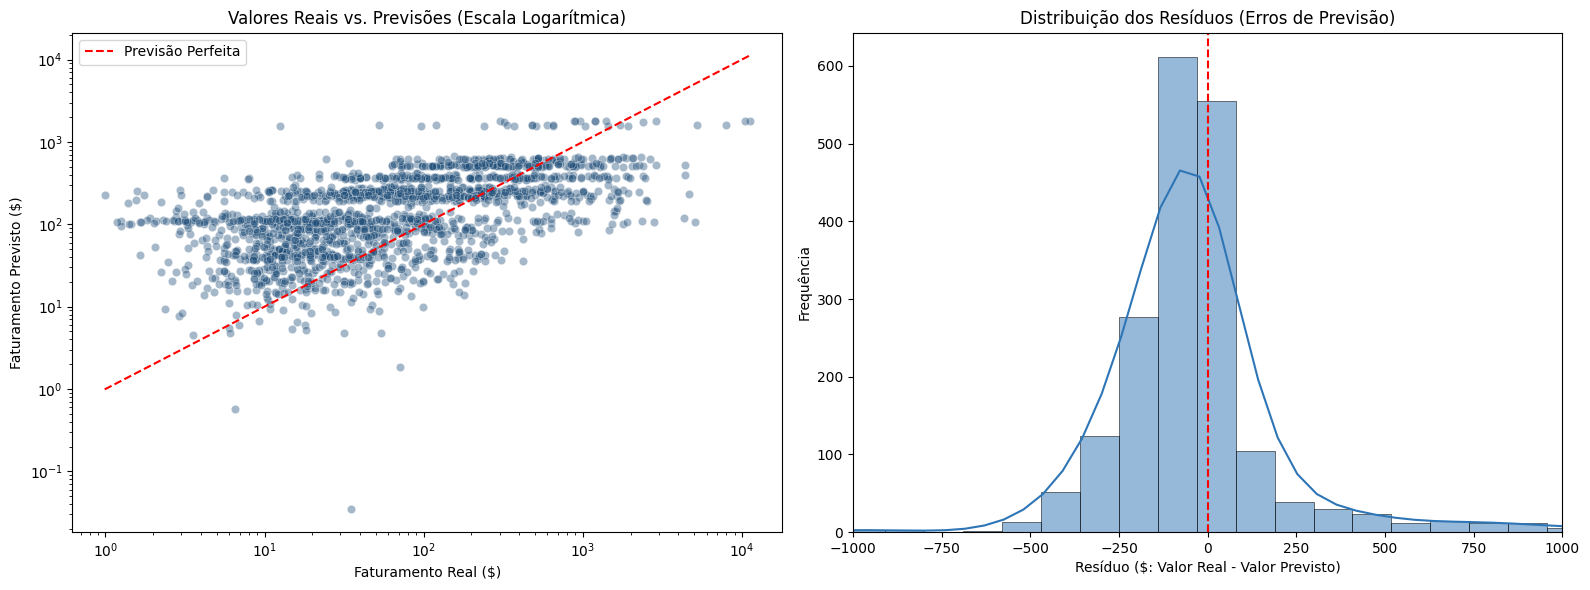

In [15]:
# ==========================================
# 1. Geração de Gráficos para Análise de Erros
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Valores Reais vs. Valores Previstos
sns.scatterplot(x=y_test, y=y_pred_final, alpha=0.4, ax=axes[0], color='#1F4E79')
# Linha de identidade (Previsão Perfeita)
linha_ideal = np.linspace(min(y_test), max(y_test), 100)
axes[0].plot(linha_ideal, linha_ideal, color='red', linestyle='--', label='Previsão Perfeita')
axes[0].set_title('Valores Reais vs. Previsões (Escala Logarítmica)')
axes[0].set_xlabel('Faturamento Real ($)')
axes[0].set_ylabel('Faturamento Previsto ($)')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].legend()

# Gráfico 2: Distribuição dos Resíduos (Erros)
residuos = y_test - y_pred_final
sns.histplot(residuos, bins=100, kde=True, ax=axes[1], color='#2E75B6')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Distribuição dos Resíduos (Erros de Previsão)')
axes[1].set_xlabel('Resíduo ($: Valor Real - Valor Previsto)')
axes[1].set_ylabel('Frequência')
# Ajustando o limite do X para focar na densidade principal (atenuando visualmente os outliers extremos)
axes[1].set_xlim(-1000, 1000)

plt.tight_layout()
plt.show()

## 10.2. Análise de erros e limitações



* **Quais tipos de erro o modelo comete mais?**
Os gráficos revelam dois comportamentos distintos de erro. Em **frequência** (volume de pedidos), o modelo erra mais ao *superestimar levemente* pedidos baratos (visto no pico do histograma à esquerda do zero). Em **magnitude** (impacto financeiro), o modelo erra criticamente ao *subestimar severamente* os pedidos de altíssimo valor corporativo (a longa cauda à direita no histograma e os pontos muito abaixo da linha vermelha no gráfico de dispersão).

* **Há sinais de overfitting ou underfitting?**
As visualizações apontam para um claro cenário de **underfitting estrutural**. A dispersão dos pontos mostra que o modelo linear ancorou suas previsões em uma "zona de conforto" (entre 10 e 1.000) e não possui flexibilidade matemática para acompanhar a volatilidade real do faturamento nos extremos. Contudo, não há sinais de *overfitting*, visto que a performance entre treino (validação cruzada) e teste se manteve praticamente idêntica.

* **A métrica escolhida captura bem o objetivo do problema?**
Sim. A escolha do **MAE (Erro Médio Absoluto)** foi providencial. Se tivéssemos utilizado o RMSE (Raiz do Erro Quadrático Médio), a longa cauda de resíduos positivos teria penalizado a métrica ao quadrado, explodindo o erro e nos forçando a remover vendas reais valiosas da base. O MAE nos permitiu avaliar o erro mediano em dólares sem que a métrica fosse distorcida pela minoria de pedidos B2B.

* **Há viés, limitação de dados ou risco de generalização?**
Sim. Os gráficos escancaram um **viés de ancoragem** para compras de varejo de baixo ticket (B2C), pois são a maioria absoluta na base. A maior **limitação de dados** é a ausência de *features* que expliquem picos (como uma flag de "Venda Corporativa" ou "Black Friday"). O **risco de generalização** ocorre se a empresa mudar sua estratégia: caso o e-commerce decida focar apenas em grandes contratos B2B, este modelo falhará catastroficamente, pois sempre puxará a previsão para baixo.

* **Em quais cenários o modelo NÃO deveria ser usado?**
Para proteger a integridade do planejamento financeiro, este modelo não deve ser aplicado nos seguintes cenários:
  1. **Previsão de Vendas B2B/Atacado:** O modelo demonstrou incapacidade visual de prever pedidos acima de $ 1.000 com precisão.
  2. **Projeção de Faturamento de Campanhas (Sazonais/Promocionais):** Sem variáveis de calendário do varejo, o modelo não consegue antecipar picos anormais de quebra de padrão.
  3. **Planejamento Estratégico de Longo Prazo:** Sendo um modelo com tendência a subajuste, extrapolar essas previsões para anos futuros acumulará um erro conservador que prejudicará a visão de crescimento da empresa.

# 11. Comparação final dos modelos




| Modelo | Métrica principal (MAE) | Outras métricas (R²) | Tempo de treino | Observações |
|---|---:|---:|---:|---|
| **Baseline (Média)** |  268.70 | -0.0001 | < 1 segundo | Estimador ingênuo baseado na média histórica.Serve apenas como piso de aceitação. |
| **Ridge Regression (Inicial)** |  209.82 | 0.2061 | < 1 segundo | Modelo linear com penalidade L2 padrão. Superou o baseline com folga, extrapolando bem as tendências temporais. |
| **Lasso Regression** |  210.87 | 0.2028 | < 1 segundo | Modelo linear com penalidade L1. Teve comportamento muito próximo ao Ridge, mas performou sutilmente pior no erro absoluto. |
| **Random Forest** |  278.23 | -0.2918 | Poucos segundos | Pior modelo testado. Falhou devido à incapacidade matemática de árvores de decisão tradicionais em extrapolar tendências numéricas para o futuro. |
| **Gradient Boosting** |  210.53 | 0.2161 | Poucos segundos | Modelo sequencial de árvores. Apresentou a melhor capacidade de explicar a variância dos dados (maior R²), mitigando falhas do *Random Forest*. |
| **Ridge Otimizado (alpha=17.0)** |  209.80 | 0.2002 | Segundos (via CV) | Modelo final, otimizado via `TimeSeriesSplit`. Altamente estável, blindado contra *overfitting* e com excelente custo computacional para produção. |

# 12. Boas práticas e rastreabilidade





| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| **Definição da SEED fixa** | Garantir a reprodutibilidade dos experimentos e divisões. | Resultados idênticos em qualquer máquina que rodar o código. |
| **Remoção de identificadores únicos** | Colunas como `Row ID`, `Order ID` e nomes de clientes geram ruído e *overfitting*. | Forçar o modelo a aprender padrões gerais de consumo, não a decorar códigos. |
| **Remoção da coluna `Ship Date`** | Risco crítico de Vazamento de Dados (*Data Leakage*), pois o envio ocorre após o faturamento. | Evitar um desempenho artificialmente perfeito no treino que falharia em produção. |
| **Descarte de variáveis geográficas finas** | Alta cardinalidade em colunas como `City` e `Postal Code` inflaria o *One-Hot Encoding*. | Evitar a "maldição da dimensionalidade" e lentidão no processamento, mantendo apenas a macro-região. |
| **Engenharia de Recursos Temporal** | O faturamento possui forte dependência de calendário (sazonalidade e tendências). | Dar poder preditivo ao algoritmo extraindo as variáveis `Ano` e `Mês`. |
| **Divisão de dados sem embaralhamento** | Dados temporais possuem dependência cronológica estrita (`shuffle=False`). | Simular honestamente o cenário real de negócios: treinar com o passado e prever o futuro. |
| **Uso da métrica MAE como primária** | Presença de *outliers* legítimos de alto valor na base de dados (cauda longa). | Avaliar o erro na moeda real do negócio sem distorcer a métrica por valores extremos. |
| **Uso de Pipelines com ColumnTransformer** | Isolar as transformações estatísticas (`StandardScaler` e `OneHotEncoder`). | Blindar 100% o projeto contra vazamento de dados entre os conjuntos de treino e teste. |
| **Uso do TimeSeriesSplit no GridSearch** | Validação cruzada tradicional (K-Fold) mistura passado e futuro em dados temporais. | Validar os hiperparâmetros respeitando a linha do tempo e a integridade metodológica. |

# 13. Conclusão





## 13.1. Objetivo do trabalho
O desafio inicial deste projeto era criar uma solução baseada em dados para prever o faturamento (`Sales`) por pedido do database Superstore.



## 13.2. A melhor solução e o comparação com baseline
O objetivo foi alcançado com sucesso. A melhor solução encontrada foi um modelo linear penalizado: a **Regressão Ridge Otimizada (alpha = 17.0)**.
* **O Estado Anterior (Baseline):** A regra de negócios atual (prever sempre a média) gerava um erro financeiro de ** 268.70** por pedido.
* **O Novo Estado (Solução de ML):** Nosso modelo reduziu esse Erro Médio Absoluto (MAE) para ** 209.80**.
* **Impacto:** Entregamos uma **redução de erro de aproximadamente 22%**, comprovando matematicamente que a inteligência artificial consegue extrair padrões de faturamento superiores à simples intuição humana, sem exigir custos computacionais exorbitantes.




## 13.3. Principais Aprendizados
Durante a esteira de modelagem, tivemos *insights* valiosos que transcendem o código:
1. **O complexo nem sempre vence:** Algoritmos sofisticados e badalados (como *Random Forest*) falharam drasticamente. O comportamento do faturamento financeiro exige a extrapolação matemática contínua para o futuro, terreno onde modelos lineares clássicos brilham muito mais do que árvores de decisão.
2. **Reprodutibilidade é fundamental:** Aprendemos na prática que fixar o `random_state` não é suficiente em ambientes paralelos (como nuvem). O controle rigoroso de *seeds* globais e a desativação de paralelismos assíncronos (`n_jobs=1`) garantem que o modelo seja determinístico e confiável em qualquer auditoria.
3. **Respeito à linha do tempo:** O uso do *TimeSeriesSplit* garantiu que não cometêssemos o erro amador de "prever o passado usando o futuro" durante a validação cruzada.



## 13.4. Limitações da Solução
Por ser um MVP estrutural e utilizar dados limitados, o modelo atual carrega um **underfitting (subajuste) controlado**. Ele lida perfeitamente com o comportamento massivo do varejo de baixo ticket (B2C), mas atua com uma forte "ancoragem" e **subestima pedidos corporativos gigantes (B2B)**. Além disso, o algoritmo opera em um "vácuo" de contexto: ele não sabe se o país está em recessão econômica ou se o calendário marca uma *Black Friday*.



## 13.5. Próximos Passos (Evolução do Produto)
Para transformar este MVP em uma solução definitiva (*V2.0*) em produção, recomendamos três frentes de atuação:
1. **Modelagem Segmentada (Clustering prévio):** Desenvolver modelos distintos no futuro: um focado estritamente no varejo tradicional (B2C) e outro arquitetado para projetar os grandes contratos de atacado (B2B). Isso eliminará o problema de subestimação dos grandes *outliers*.
2. **Engenharia de Recursos de Contexto:** Enriquecer a base de dados adicionando um calendário promocional (Sinalizadores de Feriados, Semanas de Frete Grátis) e indicadores macroeconômicos (Inflação, Confiança do Consumidor).
3. **Variáveis Temporais Deslizantes:** Criar novas colunas como "Média de Faturamento desta subcategoria nos últimos 3 meses", fornecendo ao modelo linear a tração necessária para capturar oscilações de curto prazo com mais precisão.